In [1]:
from skimage import data
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPool2D

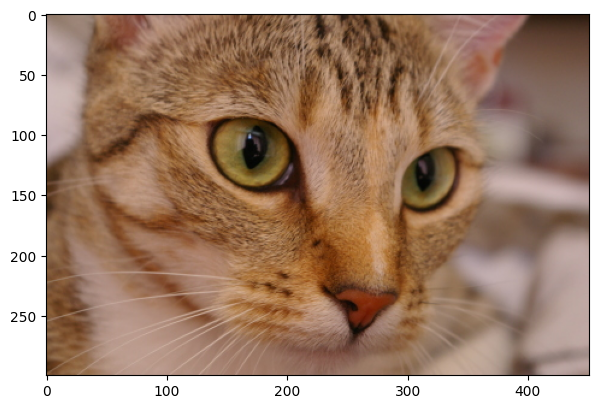

In [3]:
image = data.cat()
plt.figure(figsize=(7, 7))
plt.imshow(image);

array([[[143, 120, 104],
        [143, 120, 104],
        [141, 118, 102],
        ...,
        [ 45,  27,  13],
        [ 45,  27,  13],
        [ 45,  27,  13]],

       [[146, 123, 107],
        [145, 122, 106],
        [143, 120, 104],
        ...,
        [ 46,  29,  13],
        [ 45,  29,  13],
        [ 47,  30,  14]],

       [[148, 126, 112],
        [147, 125, 111],
        [146, 122, 109],
        ...,
        [ 48,  28,  17],
        [ 49,  29,  18],
        [ 50,  30,  19]],

       ...,

       [[ 92,  58,  30],
        [105,  71,  43],
        [132,  98,  71],
        ...,
        [172, 145, 138],
        [172, 145, 138],
        [172, 145, 138]],

       [[128,  92,  60],
        [139, 103,  71],
        [134,  95,  64],
        ...,
        [166, 142, 132],
        [166, 142, 132],
        [167, 143, 133]],

       [[139, 103,  71],
        [127,  88,  57],
        [125,  86,  53],
        ...,
        [161, 137, 127],
        [161, 137, 127],
        [162, 138, 128]]], dtype=uint8)
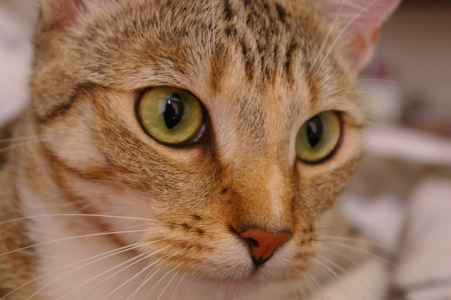

In [4]:
image

In [5]:
image = np.array([
    [3, 3, 2, 1, 0],
    [0, 0, 1, 3, 1],
    [3, 1, 2, 2, 3],
    [2, 0, 0, 2, 2],
    [2, 0, 0, 0, 1]
])

In [6]:
image

array([[3, 3, 2, 1, 0],
       [0, 0, 1, 3, 1],
       [3, 1, 2, 2, 3],
       [2, 0, 0, 2, 2],
       [2, 0, 0, 0, 1]])

In [7]:
filter = np.array([
    [0,1,2],
    [2,2,0],
    [0,1,2]
])

In [8]:
filter

array([[0, 1, 2],
       [2, 2, 0],
       [0, 1, 2]])

In [9]:
def conv(array, kernel):
  h, w = array.shape
  output_h = h - 2
  output_w = w - 2

  # Создаем выодной массив
  output = np.zeros((output_h, output_w))

  # Выполняем свертку
  for i in range(output_h):
    for j in range(output_w):
      # Вырезаем подмассив 3*3
      sub_array = array[i:i+3, j:j+3]
      # Вычисляем скалярное произведение
      output[i, j] = np.sum(sub_array * kernel)

  return output

In [10]:
conv(image, filter)

array([[12., 12., 17.],
       [10., 17., 19.],
       [ 9.,  6., 14.]])

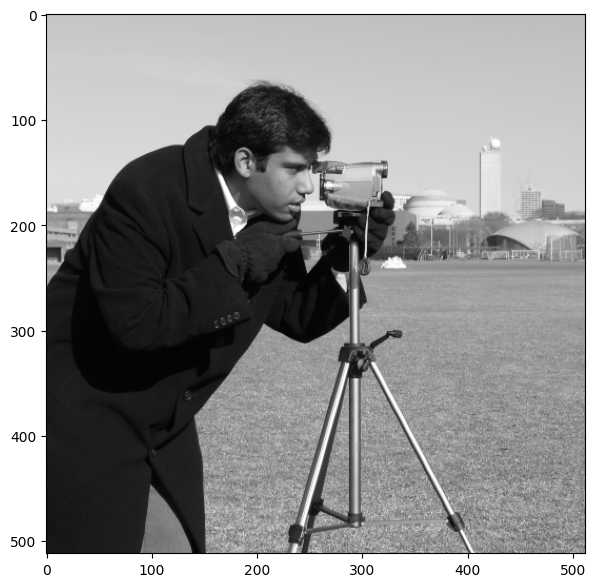

In [11]:
image = data.camera()
plt.figure(figsize=(7, 7))
plt.imshow(image, cmap='gray');

In [12]:
image.shape

(512, 512)

In [13]:
image = image [None,...,None]
image.shape

(1, 512, 512, 1)

In [14]:
image = image.astype(np.float32)

In [15]:
conv_layer = Conv2D(kernel_size=(3,3), filters = 1)

In [16]:
image_conv = conv_layer(image)

In [17]:
image_conv.shape

TensorShape([1, 510, 510, 1])

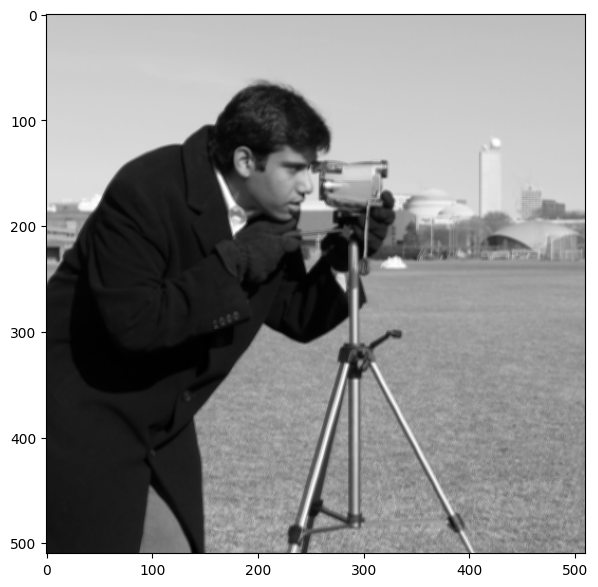

In [18]:
plt.figure(figsize=(7, 7))
plt.imshow(image_conv[0, :, :, 0], cmap='gray');

In [19]:
conv_layer = Conv2D(kernel_size=(3,3), filters = 1, padding='same')

In [20]:
image_conv = conv_layer(image)

In [21]:
image_conv.shape

TensorShape([1, 512, 512, 1])

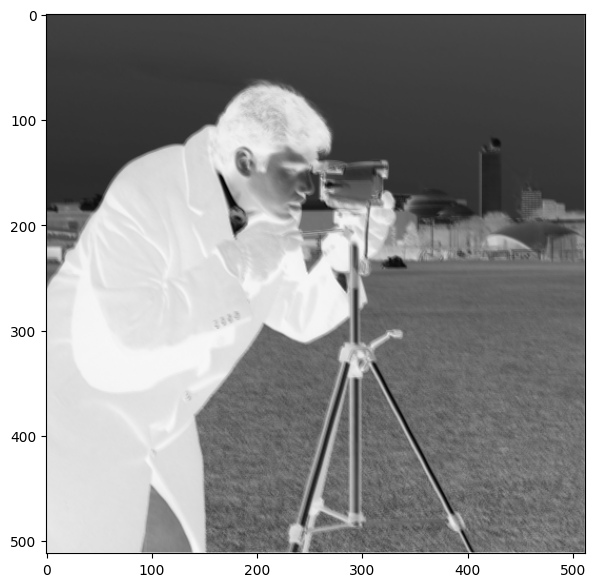

In [22]:
plt.figure(figsize=(7,7))
plt.imshow(image_conv[0,:,:,0], cmap='gray')

# Классификация одежды

In [23]:
mapping = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

In [24]:
def show_mnist(images,labels, predicted_labels=None):
  plt.figure(figsize=(10,10))
  for i in range(16):
    plt.subplot(4,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(images[i], cmap=plt.cm.gray)
    if predicted_labels is not None:
      title_obj = plt.title(f'Real: {labels[i]}. Pred: {predicted_labels[i]}')
      if labels[i] != predicted_labels[i]:
        plt.setp(title_obj, color = 'r')
    else:
      plt.title(f'Real label: {labels[i]}')

In [25]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


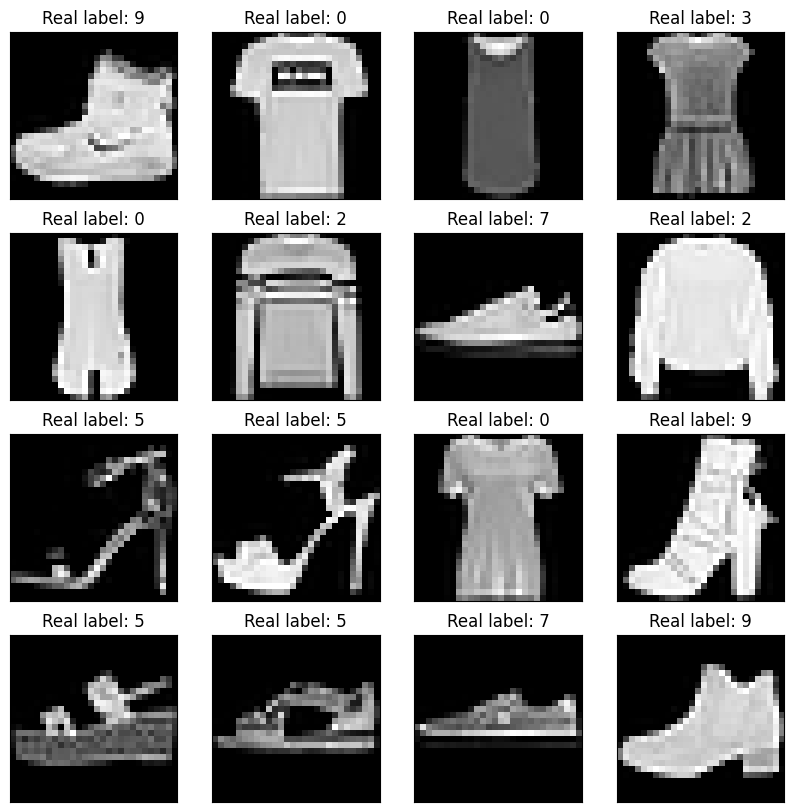

In [26]:
show_mnist(x_train, y_train)

In [27]:
x_train.shape

(60000, 28, 28)

In [28]:
x_test.shape

(10000, 28, 28)

In [29]:
model = tf.keras.models.Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(512, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [30]:
model.compile(optimizer='adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

In [31]:
model.fit(x=x_train, y=y_train,
          batch_size=128, epochs = 15,
          validation_data = (x_test, y_test))

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7064 - loss: 29.3871 - val_accuracy: 0.7610 - val_loss: 3.0608
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8030 - loss: 1.6150 - val_accuracy: 0.8075 - val_loss: 0.7384
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8277 - loss: 0.5642 - val_accuracy: 0.8224 - val_loss: 0.5711
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8533 - loss: 0.4234 - val_accuracy: 0.8342 - val_loss: 0.5317
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8627 - loss: 0.3812 - val_accuracy: 0.8434 - val_loss: 0.4946
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8714 - loss: 0.3551 - val_accuracy: 0.8255 - val_loss: 0.5663
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8770 - loss: 0.3421 - val_accuracy: 0.8321 - val_loss: 0.5399
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8709 - loss: 0.3575 - val_accuracy: 0

In [32]:
model.evaluate (x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8524 - loss: 0.4842


[0.5015937089920044, 0.8475000262260437]

In [33]:
x_tain = x_train[..., None]
x_test = x_test[..., None]

In [34]:
x_train.shape

(60000, 28, 28)

In [35]:
x_test.shape

(10000, 28, 28, 1)

In [36]:
model = tf.keras.Sequential()
model.add(Conv2D(filters = 32, kernel_size=(3,3), padding = 'same',
                 activation='relu', input_shape= (28, 28, 1)))
model.add(MaxPool2D(pool_size=2))
model.add(Conv2D(filters=64, kernel_size=(3, 3), padding='same',
                 activation='relu'))
model.add(MaxPool2D(pool_size=2))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='relu'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.compile(optimizer='adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

In [38]:
model.fit(x=x_train, y=y_train,
          batch_size = 128, epochs = 20,
          validation_data = (x_test, y_test))

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.0988 - loss: 10.9467 - val_accuracy: 0.1000 - val_loss: 11.0571
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0993 - loss: 11.0217 - val_accuracy: 0.1000 - val_loss: 11.0571
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1005 - loss: 11.0696 - val_accuracy: 0.1000 - val_loss: 11.0571
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1011 - loss: 11.0698 - val_accuracy: 0.1000 - val_loss: 11.0571
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0982 - loss: 11.0559 - val_accuracy: 0.1000 - val_loss: 11.0571
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0997 - loss: 11.0563 - val_accuracy: 0.1000 - val_loss: 11.0571
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1031 - loss: 11.0834 - val_accuracy: 0.1000 - val_loss: 11.0571
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0973 - loss: 11.1108 - 

In [39]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.0978 - loss: 11.0175


[11.057143211364746, 0.10000000149011612]

In [40]:
predicted_labels = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [41]:
classes_x = np.argmax(predicted_labels, axis=1)
idx = np.random.choice(np.arange(len(x_test)), 16, replace=False)

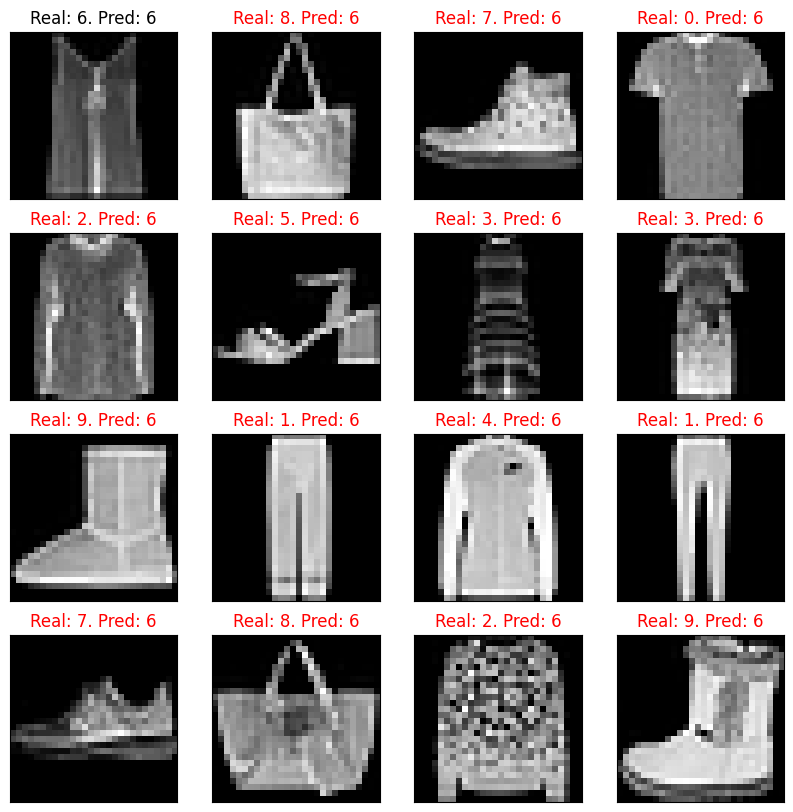

In [42]:
show_mnist(x_test[idx].reshape((-1, 28, 28)), y_test[idx], classes_x[idx])